In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dataset 1 : Retail Sales EDA

In [4]:
df = pd.read_csv("store_sales.csv")

print(df.head())
print(df.shape)

   CustomerID  Age  Gender       Category ItemPurchased  Amount  Season  \
0           1   58  Female    Accessories       Handbag  115.50  Autumn   
1           2   40    Male  Mens Clothing         Shirt  103.43  Spring   
2           3   66  Female         Sports      Football   35.45  Spring   
3           4   39  Female    Accessories       Handbag  153.31  Spring   
4           5   23  Female           Home      Curtains  151.43  Winter   

  PaymentMethod  ItemRating  DiscountApplied(%)  PreviousPurchases  
0          Card         3.5                  18                  4  
1          Card         4.1                  13                  4  
2          Card         3.3                  11                  3  
3          Card         4.4                  13                  4  
4          Card         4.1                  20                 10  
(5000, 11)


In [5]:
print(df.info())

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   object 
 3   Category            5000 non-null   object 
 4   ItemPurchased       5000 non-null   object 
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   object 
 7   PaymentMethod       5000 non-null   object 
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 429.8+ KB
None

Columns:
Index(['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount',
       'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)',
       'PreviousPurchases'],
 

In [6]:
print(df.describe())

        CustomerID          Age       Amount   ItemRating  DiscountApplied(%)  \
count  5000.000000  5000.000000  5000.000000  5000.000000         5000.000000   
mean   2500.500000    45.224800   285.090522     3.784160           14.983600   
std    1443.520003    14.564995   551.454382     0.681796            5.988063   
min       1.000000    20.000000     5.080000     1.100000            0.000000   
25%    1250.750000    33.000000    70.547500     3.300000           11.000000   
50%    2500.500000    45.000000   122.485000     3.800000           15.000000   
75%    3750.250000    58.000000   184.535000     4.300000           19.000000   
max    5000.000000    70.000000  2997.940000     5.000000           36.000000   

       PreviousPurchases  
count        5000.000000  
mean            5.008800  
std             2.194285  
min             0.000000  
25%             3.000000  
50%             5.000000  
75%             6.000000  
max            13.000000  


In [7]:
print("Mean Amount:", df["Amount"].mean())
print("Median Amount:", df["Amount"].median())
print("Mode Amount:", df["Amount"].mode()[0])
print("Standard Deviation:", df["Amount"].std())

Mean Amount: 285.09052199999996
Median Amount: 122.485
Mode Amount: 108.5
Standard Deviation: 551.4543821742568


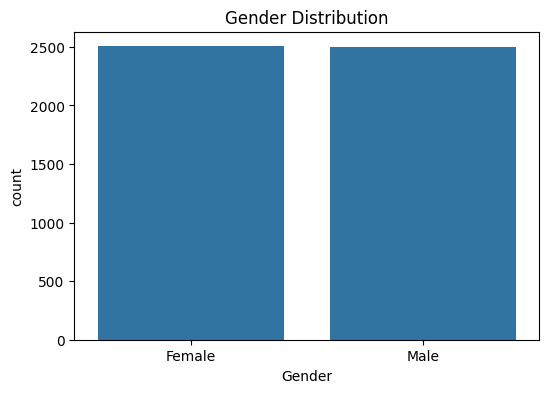

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.show()

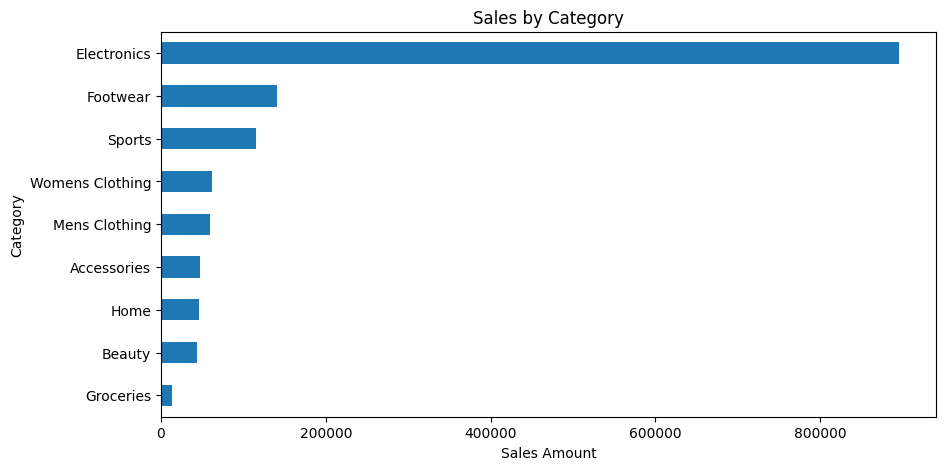

In [9]:
category_sales = df.groupby("Category")["Amount"].sum()

plt.figure(figsize=(10,5))
category_sales.sort_values().plot(kind="barh")

plt.title("Sales by Category")
plt.xlabel("Sales Amount")
plt.show()

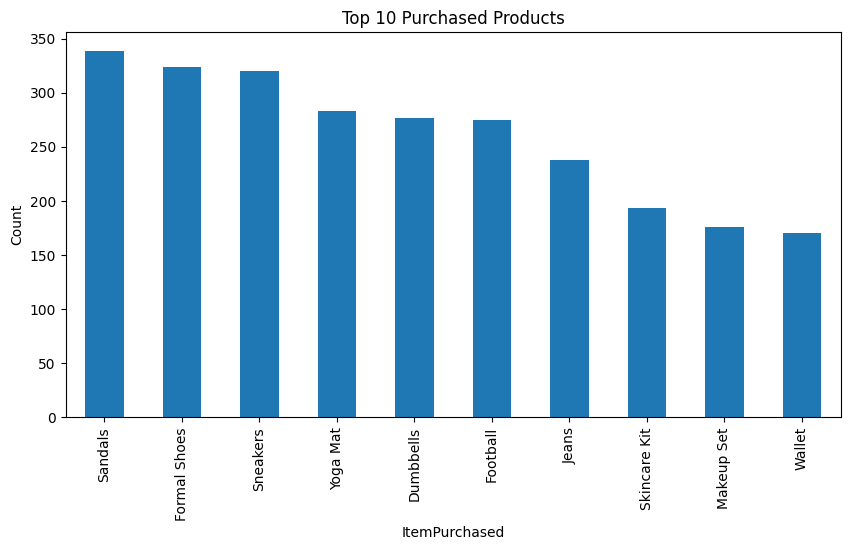

In [10]:
top_products = df["ItemPurchased"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")

plt.title("Top 10 Purchased Products")
plt.ylabel("Count")
plt.show()

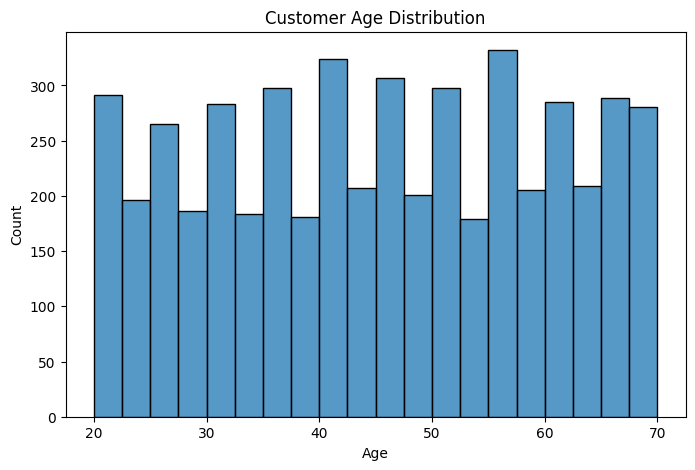

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)

plt.title("Customer Age Distribution")
plt.show()

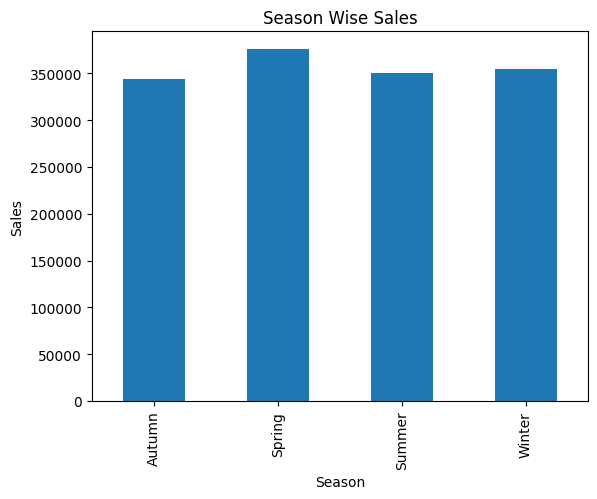

In [12]:
season_sales = df.groupby("Season")["Amount"].sum()

season_sales.plot(kind="bar")

plt.title("Season Wise Sales")
plt.ylabel("Sales")
plt.show()

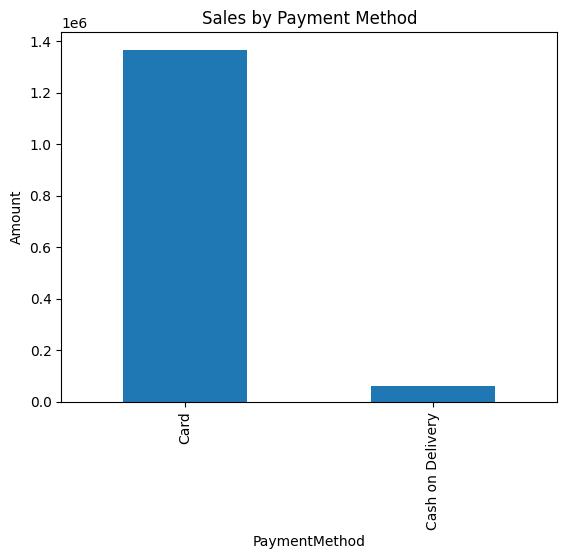

In [13]:
payment_sales = df.groupby("PaymentMethod")["Amount"].sum()

payment_sales.plot(kind="bar")

plt.title("Sales by Payment Method")
plt.ylabel("Amount")
plt.show()

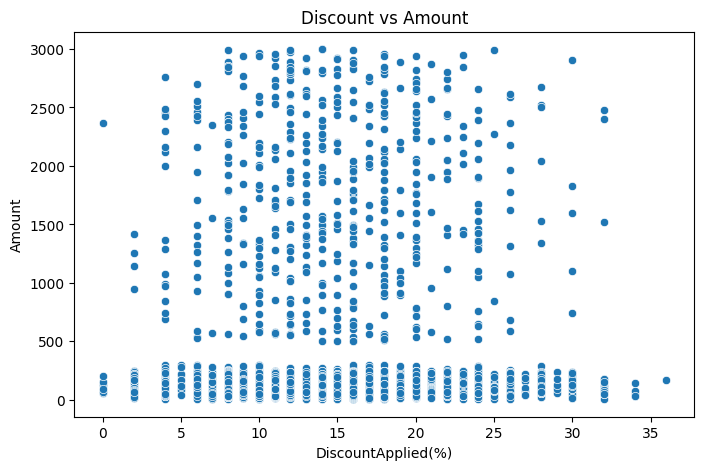

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="DiscountApplied(%)",
    y="Amount",
    data=df
)

plt.title("Discount vs Amount")
plt.show()

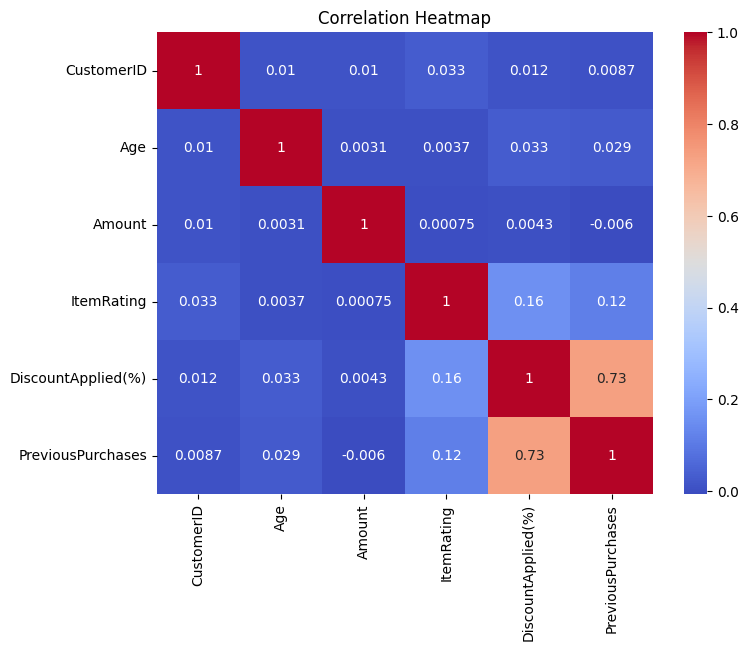

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

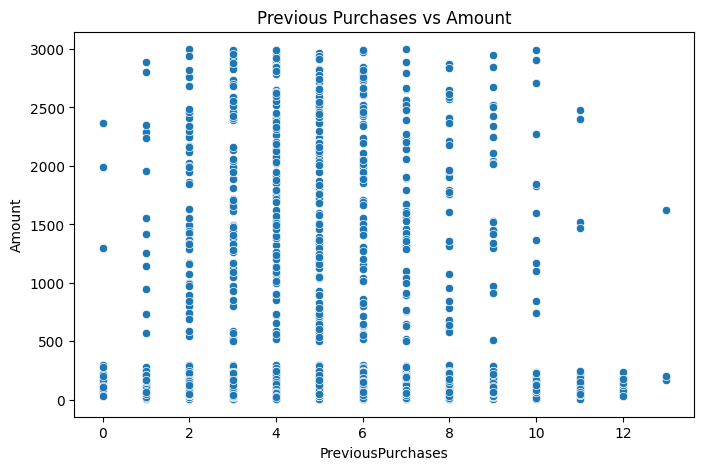

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="PreviousPurchases",
    y="Amount",
    data=df
)

plt.title("Previous Purchases vs Amount")
plt.show()

Dataset 2 : Food Menu EDA

In [17]:
menu = pd.read_csv("menu.csv")

menu.head()

,Category,Item,Serving Size,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
0,Breakfast,Egg McMuffin,4.8 oz (136 g),300,120,13.0,20,5.0,25,0.0,...,31,10,4,17,3,17,10,0,25,15
1,Breakfast,Egg White Delight,4.8 oz (135 g),250,70,8.0,12,3.0,15,0.0,...,30,10,4,17,3,18,6,0,25,8
2,Breakfast,Sausage McMuffin,3.9 oz (111 g),370,200,23.0,35,8.0,42,0.0,...,29,10,4,17,2,14,8,0,25,10
3,Breakfast,Sausage McMuffin with Egg,5.7 oz (161 g),450,250,28.0,43,10.0,52,0.0,...,30,10,4,17,2,21,15,0,30,15
4,Breakfast,Sausage McMuffin with Egg Whites,5.7 oz (161 g),400,210,23.0,35,8.0,42,0.0,...,30,10,4,17,2,21,6,0,25,10


In [18]:
menu.info()

menu.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Category                       260 non-null    object 
 1   Item                           260 non-null    object 
 2   Serving Size                   260 non-null    object 
 3   Calories                       260 non-null    int64  
 4   Calories from Fat              260 non-null    int64  
 5   Total Fat                      260 non-null    float64
 6   Total Fat (% Daily Value)      260 non-null    int64  
 7   Saturated Fat                  260 non-null    float64
 8   Saturated Fat (% Daily Value)  260 non-null    int64  
 9   Trans Fat                      260 non-null    float64
 10  Cholesterol                    260 non-null    int64  
 11  Cholesterol (% Daily Value)    260 non-null    int64  
 12  Sodium                         260 non-null    int

,Calories,Calories from Fat,Total Fat,Total Fat (% Daily Value),Saturated Fat,Saturated Fat (% Daily Value),Trans Fat,Cholesterol,Cholesterol (% Daily Value),Sodium,...,Carbohydrates,Carbohydrates (% Daily Value),Dietary Fiber,Dietary Fiber (% Daily Value),Sugars,Protein,Vitamin A (% Daily Value),Vitamin C (% Daily Value),Calcium (% Daily Value),Iron (% Daily Value)
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,368.269231,127.096154,14.165385,21.815385,6.007692,29.965385,0.203846,54.942308,18.392308,495.750000,...,47.346154,15.780769,1.630769,6.530769,29.423077,13.338462,13.426923,8.534615,20.973077,7.734615
std,240.269886,127.875914,14.205998,21.885199,5.321873,26.639209,0.429133,87.269257,29.091653,577.026323,...,28.252232,9.419544,1.567717,6.307057,28.679797,11.426146,24.366381,26.345542,17.019953,8.723263
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,210.000000,20.000000,2.375000,3.750000,1.000000,4.750000,0.000000,5.000000,2.000000,107.500000,...,30.000000,10.000000,0.000000,0.000000,5.750000,4.000000,2.000000,0.000000,6.000000,0.000000
50%,340.000000,100.000000,11.000000,17.000000,5.000000,24.000000,0.000000,35.000000,11.000000,190.000000,...,44.000000,15.000000,1.000000,5.000000,17.500000,12.000000,8.000000,0.000000,20.000000,4.000000
75%,500.000000,200.000000,22.250000,35.000000,10.000000,48.000000,0.000000,65.000000,21.250000,865.000000,...,60.000000,20.000000,3.000000,10.000000,48.000000,19.000000,15.000000,4.000000,30.000000,15.000000
max,1880.000000,1060.000000,118.000000,182.000000,20.000000,102.000000,2.500000,575.000000,192.000000,3600.000000,...,141.000000,47.000000,7.000000,28.000000,128.000000,87.000000,170.000000,240.000000,70.000000,40.000000


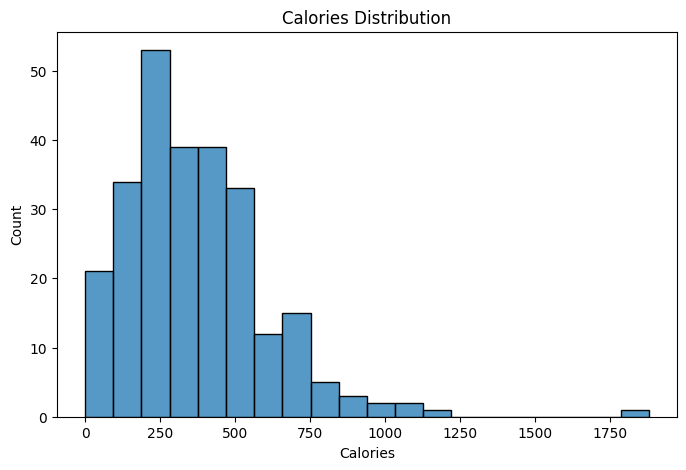

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(menu["Calories"], bins=20)

plt.title("Calories Distribution")
plt.show()

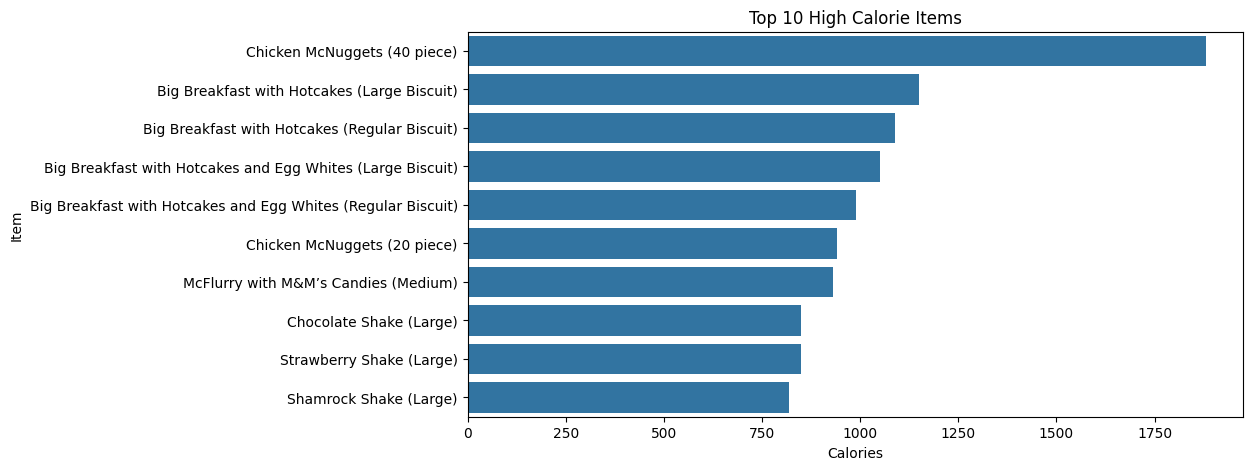

In [20]:
top_calories = menu.sort_values(
    by="Calories",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x="Calories",
    y="Item",
    data=top_calories
)

plt.title("Top 10 High Calorie Items")
plt.show()

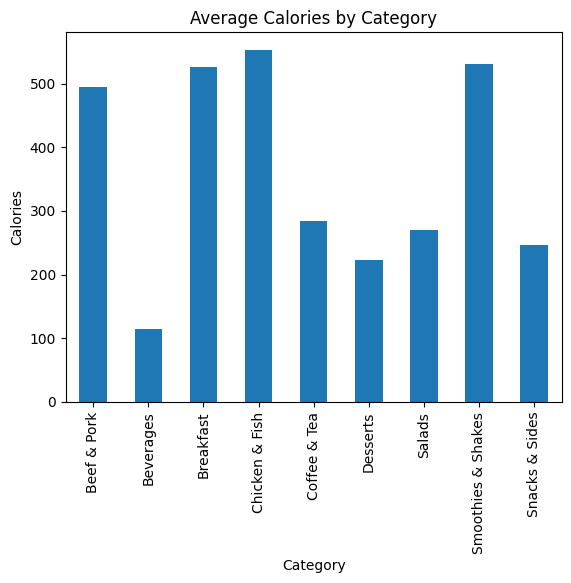

In [21]:
avg_calories = menu.groupby(
    "Category"
)["Calories"].mean()

avg_calories.plot(kind="bar")

plt.title("Average Calories by Category")
plt.ylabel("Calories")
plt.show()

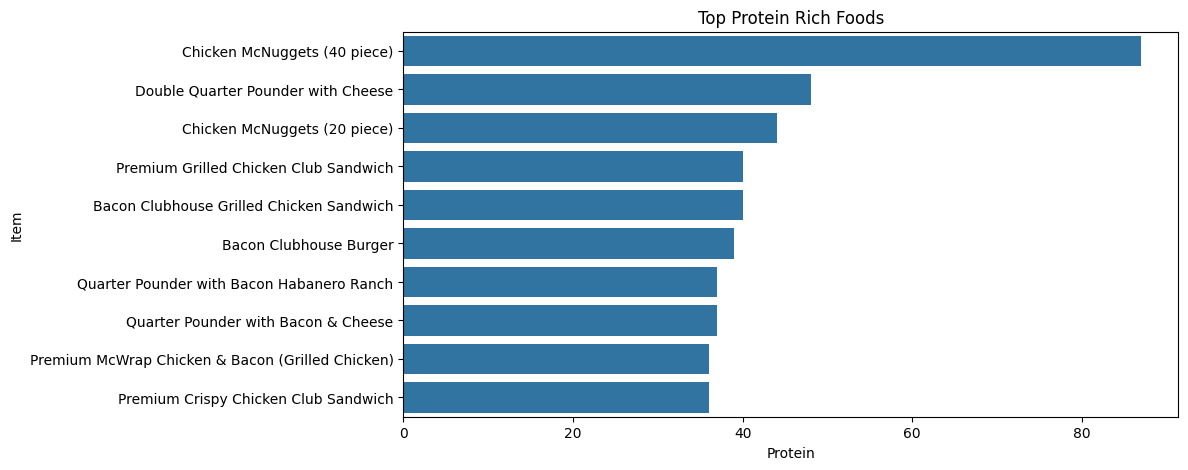

In [22]:
top_protein = menu.sort_values(
    by="Protein",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x="Protein",
    y="Item",
    data=top_protein
)

plt.title("Top Protein Rich Foods")
plt.show()

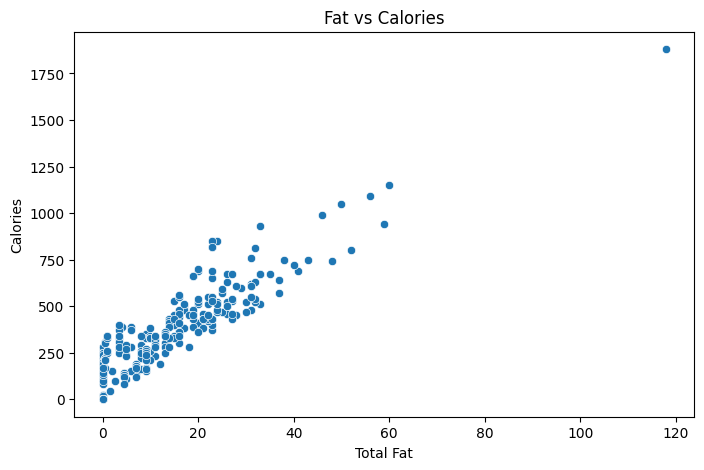

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Total Fat",
    y="Calories",
    data=menu
)

plt.title("Fat vs Calories")
plt.show()

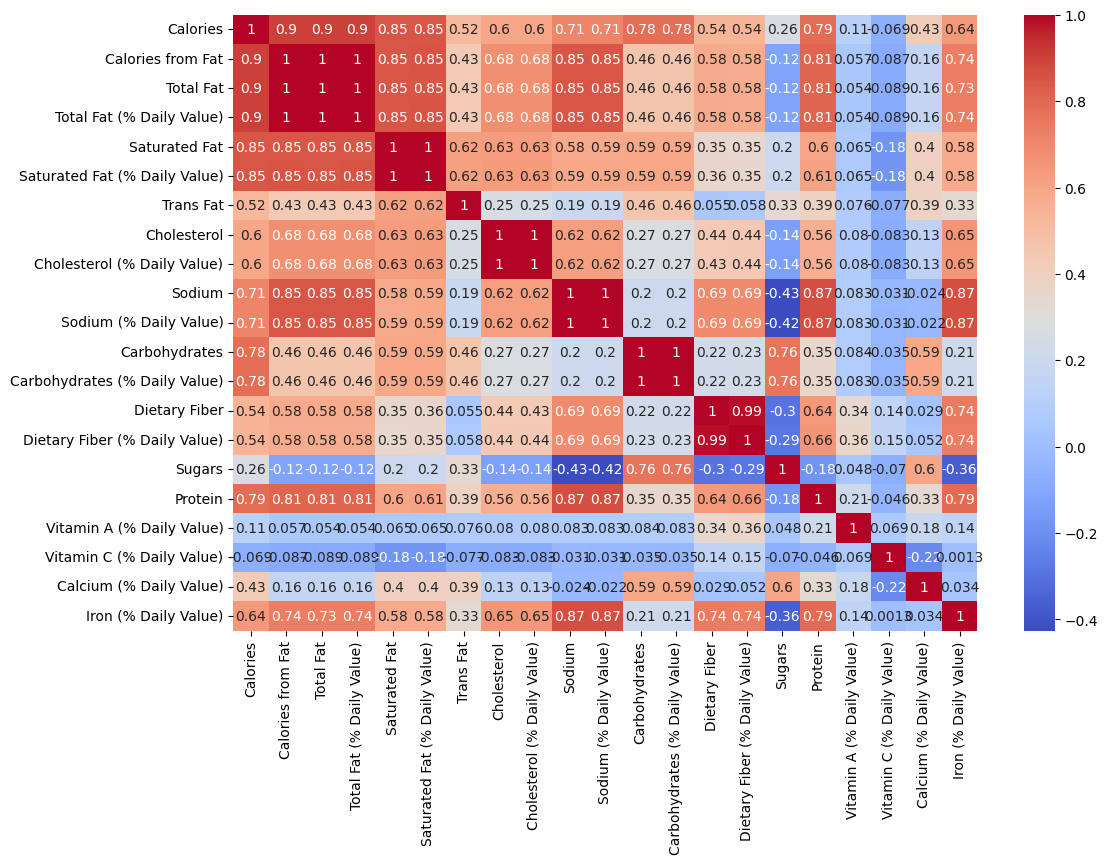

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
    menu.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()